Практика **4.1**
Студент **Молокеев Артём Валерьевич**
Вариант **17**

Часть кода взята на прямую с сайта https://habr.com/ru/articles/1015102/


**Задание 1**

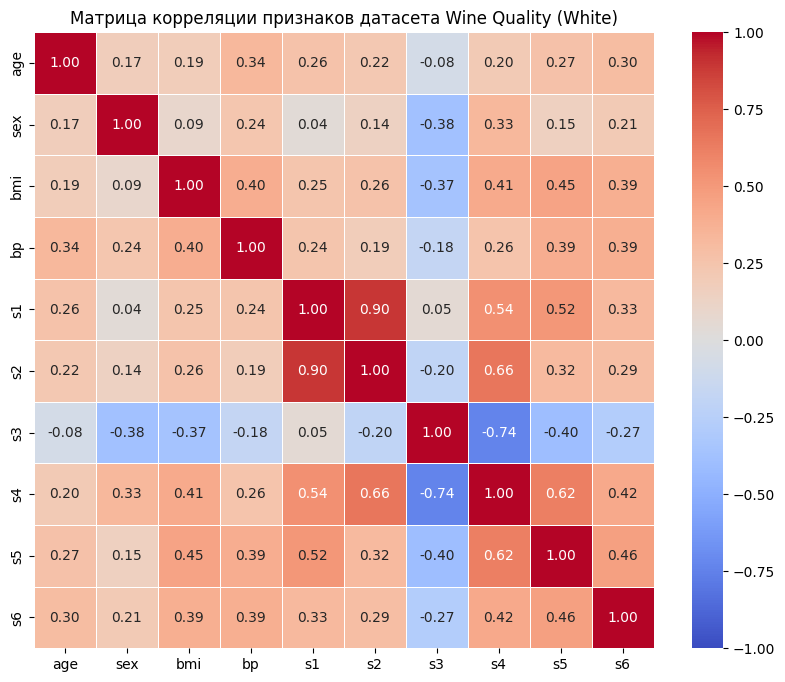

        Model       RMSE  Non-zero coefs
0       Ridge  53.485346              10
1       Lasso  53.496765               9
2  ElasticNet  53.495797               9

ElasticNet best alpha: 0.09236708571873865
ElasticNet best l1_ratio: 1.0


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Загружаем датасет 'diabetes' из scikit-learn
data = load_diabetes()
# Разделяем данные на признаки (X) и целевую переменную (y)
X, y = data.data, data.target

# Создаем DataFrame из признаков для удобства анализа и визуализации
df_features = pd.DataFrame(X, columns=data.feature_names)
# Вычисляем матрицу корреляции между признаками
corr_matrix = df_features.corr()

# Создаем тепловую карту (heatmap) для визуализации матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, # Показываем значения корреляции на карте
    cmap='coolwarm', # Цветовая схема
    fmt=".2f", # Формат чисел (2 знака после запятой)
    linewidths=0.5, # Ширина линий между ячейками
    vmin=-1, vmax=1 # Диапазон значений для цветовой шкалы
)
plt.title("Матрица корреляции признаков датасета Wine Quality (White)") # Заголовок графика
plt.show()

# Определяем пайплайн для Ridge-регрессии
# 1. StandardScaler(): Масштабирует признаки для улучшения сходимости моделей.
# 2. Ridge(alpha=1.0): Применяет Ridge-регрессию с параметром регуляризации alpha=1.0.
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

# Определяем пайплайн для Lasso-регрессии
# 1. StandardScaler(): Масштабирует признаки.
# 2. Lasso(alpha=0.1, max_iter=10000): Применяет Lasso-регрессию с alpha=0.1 и увеличенным количеством итераций.
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.1, max_iter=10000))
])

# Определяем пайплайн для ElasticNet-регрессии с кросс-валидацией
# 1. StandardScaler(): Масштабирует признаки.
# 2. ElasticNetCV(...): Выполняет кросс-валидацию для подбора оптимальных alpha и l1_ratio.
#    - l1_ratio: Список значений для соотношения L1/L2 регуляризации.
#    - alphas: Диапазон значений для параметра регуляризации alpha.
#    - cv=5: Использует 5-кратную кросс-валидацию.
#    - max_iter=10000: Увеличенное количество итераций.
elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9, 1],
        alphas=np.logspace(-2, 5, 30),
        cv=5,
        max_iter=10000
    ))
])

# Словарь с моделями для удобного итерирования
models = {
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic
}

# Список для хранения результатов по каждой модели
results = []

# Обучаем каждую модель, делаем предсказания и оцениваем результаты
for name, model in models.items():
    model.fit(X, y) # Обучаем модель на всех данных
    y_pred = model.predict(X) # Делаем предсказания

    # Вычисляем среднеквадратичную ошибку (RMSE)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    # Извлекаем коэффициенты модели
    coefs = model.named_steps['model'].coef_
    # Считаем количество ненулевых коэффициентов (для Lasso/ElasticNet - признак отбора признаков)
    non_zero = np.sum(coefs != 0)

    results.append([name, rmse, non_zero]) # Добавляем результаты в список

# Создаем DataFrame из результатов для наглядного сравнения моделей
df = pd.DataFrame(results, columns=["Model", "RMSE", "Non-zero coefs"])
print(df)

# Извлекаем лучшую alpha и l1_ratio для ElasticNet модели
elastic_model = elastic.named_steps['model']
print("\nElasticNet best alpha:", elastic_model.alpha_)
print("ElasticNet best l1_ratio:", elastic_model.l1_ratio_)

На кросс-валидации ElasticNet выбрал `l1_ratio = 1.0` (то есть фактически стал Lasso-регрессией) и `best alpha: 0.092367`. В датасете Diabetes, по всей видимости, присутствовал один избыточный признак, поскольку Lasso-регрессия смогла исключить его (оставив 9 ненулевых коэффициентов) и при этом достичь практически такой же точности предсказания (RMSE) как и Ridge-регрессия, которая использовала все 10 признаков.

**Задание 2**

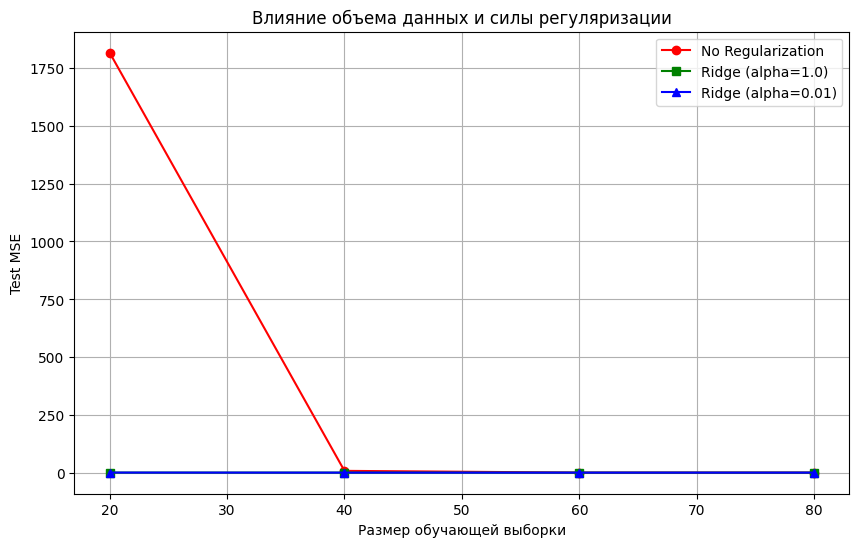

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# Устанавливаем seed для воспроизводимости результатов
np.random.seed(42)

# Генерируем синтетические данные для демонстрации полиномиальной регрессии
# X - одномерный массив от -3 до 3
# y - функция синуса от X с добавлением случайного шума
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

# Определяем размеры обучающих выборок для тестирования
sizes = [20, 40, 60, 80]

# Списки для хранения ошибок MSE для каждой модели при разных размерах выборки
linear_errors = []
ridge_strong_errors = []
ridge_weak_errors = []

# Итерируемся по различным размерам обучающей выборки
for size in sizes:
    # Разделяем данные на обучающую и тестовую выборки
    # train_size=size определяет количество точек в обучающей выборке
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=size, random_state=42)

    # Определяем пайплайн для линейной регрессии (без регуляризации)
    # 1. PolynomialFeatures(degree=15): Создает полиномиальные признаки до 15-й степени.
    # 2. StandardScaler(): Масштабирует признаки.
    # 3. Ridge(alpha=0): Применяет Ridge-регрессию с alpha=0, что эквивалентно обычной линейной регрессии.
    model_lin = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0))
    ])

    # Определяем пайплайн для Ridge-регрессии с сильной регуляризацией (alpha=1.0)
    model_ridge_strong = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ])

    # Определяем пайплайн для Ridge-регрессии со слабой регуляризацией (alpha=0.01)
    model_ridge_weak = Pipeline([
        ('poly', PolynomialFeatures(degree=15)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=0.01))
    ])

    # Обучаем все три модели на текущей обучающей выборке
    model_lin.fit(X_train, y_train)
    model_ridge_strong.fit(X_train, y_train)
    model_ridge_weak.fit(X_train, y_train)

    # Делаем предсказания на тестовой выборке для каждой модели
    y_pred_lin = model_lin.predict(X_test)
    y_pred_ridge_strong = model_ridge_strong.predict(X_test)
    y_pred_ridge_weak = model_ridge_weak.predict(X_test)

    # Вычисляем и сохраняем среднеквадратичную ошибку (MSE) для каждой модели
    linear_errors.append(mean_squared_error(y_test, y_pred_lin))
    ridge_strong_errors.append(mean_squared_error(y_test, y_pred_ridge_strong))
    ridge_weak_errors.append(mean_squared_error(y_test, y_pred_ridge_weak))

# Визуализация результатов
plt.figure(figsize=(10, 6))
# Строим график MSE для линейной регрессии (без регуляризации) в зависимости от размера выборки
plt.plot(sizes, linear_errors, marker='o', color='red', label='No Regularization')
# Строим график MSE для Ridge-регрессии с сильной регуляризацией
plt.plot(sizes, ridge_strong_errors, marker='s', color='green', label='Ridge (alpha=1.0)')
# Строим график MSE для Ridge-регрессии со слабой регуляризацией
plt.plot(sizes, ridge_weak_errors, marker='^', color='blue', label='Ridge (alpha=0.01)')

# Добавляем подписи осей, заголовок и легенду к графику
plt.xlabel("Размер обучающей выборки")
plt.ylabel("Test MSE")
plt.title("Влияние объема данных и силы регуляризации")
plt.legend()
plt.grid()
plt.show()

При малом объеме обучающих данных (например, 20 точек), регуляризация (особенно сильная, как `Ridge alpha=1.0`) значительно улучшает качество модели, резко снижая ошибку (Test MSE) за счет предотвращения переобучения.

По мере увеличения объема данных, преимущество регуляризации становится менее выраженным, и ошибки всех моделей (как с регуляризацией, так и без нее) сближаются, так как данных становится достаточно для обучения стабильной модели даже без дополнительных ограничений.

Данные выводы были взяты с сайта из-за практически идентичных графиком и решаемой задачи.()

**Задание 3**

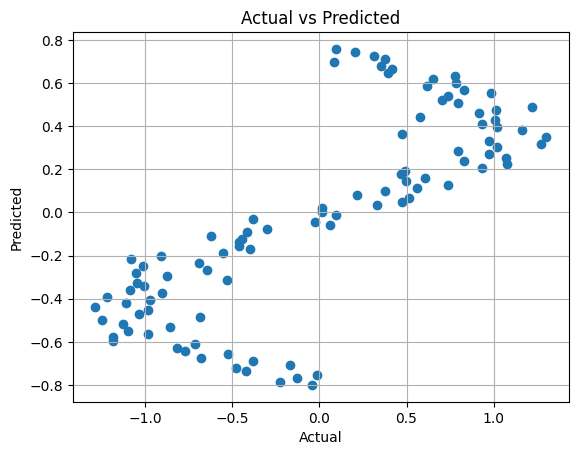

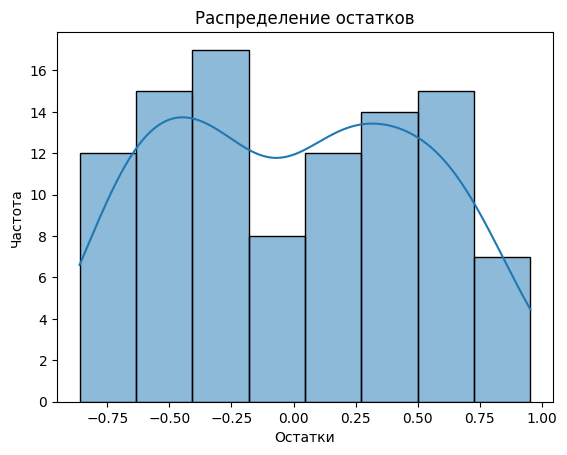

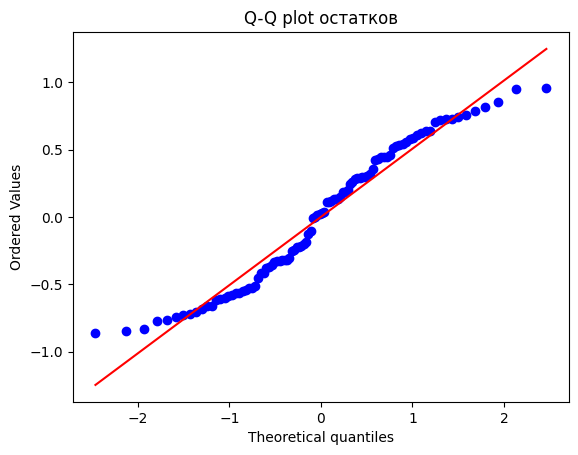

Shapiro p-value: 0.0014249778427384168


In [22]:
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt # Импортируем plt, если еще не импортирован

# Выбираем лучшую модель для анализа остатков.
# В данном случае, это ElasticNet, который показал хорошие результаты
# по RMSE и способности к отбору признаков.
best_model = elastic
best_model.fit(X, y)

# Вычисляем предсказания модели и остатки (разница между фактическими и предсказанными значениями)
y_pred = best_model.predict(X)
residuals = y - y_pred

# 1. График 'Actual vs Predicted'
# Показывает взаимосвязь между истинными значениями (y) и предсказанными моделью (y_pred).
# Идеальная модель должна иметь точки, расположенные вдоль диагональной линии.
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid()
plt.show()

# 2. Гистограмма остатков
# Визуализирует распределение остатков модели. Для хорошей модели остатки
# должны быть распределены нормально вокруг нуля.
sns.histplot(residuals, kde=True)
plt.title("Распределение остатков") # Изменено на русский язык для согласованности
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.show()

# 3. Q-Q plot (Quantile-Quantile plot)
# Сравнивает квантили остатков с квантилями нормального распределения.
# Если остатки распределены нормально, точки должны лежать близко к прямой линии.
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot остатков") # Изменено на русский язык
plt.show()

# 4. Тест Шапиро-Уилка
# Проверяет нулевую гипотезу о том, что выборка данных (остатки)
# была взята из нормально распределенной генеральной совокупности.
# Низкое p-значение (обычно < 0.05) указывает на отклонение от нормальности.
stat, p = stats.shapiro(residuals)
print("Shapiro p-value:", p)

График Actual vs Predicted показывает выраженную нелинейную структуру данных - точки образуют петли, а не ровную линию. Линейная модель (в данном случае ElasticNet) не способна описать такую сложную зависимость, из-за чего возникают систематические крупные ошибки предсказания. Именно эта нелинейность взаимосвязей и является причиной того, что остатки модели распределены ненормально. Гетероскедастичности (разного масштаба ошибок) здесь нет, так как ширина этого облака точек остается примерно одинаковой на всем протяжении диапазона — точки не расходятся веером